## 1. Load the Clustered Dataset

The clustering phase is now completed.
The dataset contains the patient clinical variables, the cluster assigned by K-Means, and the final `risk_category`.

In this notebook, we will use `risk_category` as the target variable for supervised classification.


In [19]:
import pandas as pd

df = pd.read_csv("../data/processed/diabetes_clustered.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster,risk_category
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0,2,Low Risk
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0,0,Low Risk
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0,2,Low Risk
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Low Risk
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,High Risk


In [20]:
df.shape

(768, 10)

In [21]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Cluster', 'risk_category'],
      dtype='str')

## 2. Define Features and Target

`X` contains the clinical variables used to make the prediction.

`y` contains the risk category that the model must predict.

We don't use `Cluster` as a feature because it was used to create `risk_category`.


In [22]:
clinical_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[clinical_columns]
y = df["risk_category"]

In [23]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


In [24]:
y.head()

0     Low Risk
1     Low Risk
2     Low Risk
3     Low Risk
4    High Risk
Name: risk_category, dtype: str

## 3. Check Target Distribution

We check how many patients belong to each risk category.

This tells us whether the classes are balanced or imbalanced.


In [25]:
y.value_counts()

risk_category
Low Risk     568
High Risk    200
Name: count, dtype: int64

In [26]:
y.value_counts(normalize=True) * 100 # get percentage of each class

risk_category
Low Risk     73.958333
High Risk    26.041667
Name: proportion, dtype: float64

## 4. Train/Test Split

We split the dataset into training and testing data.

The model learns from the training data and is evaluated on the unseen test data.

`stratify=y` keeps a similar proportion of Low Risk and High Risk patients in both sets.


In [27]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #preserves the existing ratio
)

In [28]:
X_train.shape , X_test.shape

((614, 8), (154, 8))

In [29]:
y_train.value_counts()

risk_category
Low Risk     454
High Risk    160
Name: count, dtype: int64

In [30]:
y_test.value_counts()

risk_category
Low Risk     114
High Risk     40
Name: count, dtype: int64

## 6. Handle Class Imbalance with Scaling and SMOTE

The training dataset contains fewer **High Risk** patients than **Low Risk** patients.

Before applying SMOTE, we standardize the numerical features because SMOTE uses distances to find similar minority-class samples.

The steps are:

1. Standardize the training and test features using `StandardScaler`.
2. Apply `SMOTE` only to the scaled training data.
3. Keep the test data unchanged because it must represent unseen real data.
4. Check that the two classes are balanced after SMOTE.

SMOTE creates synthetic samples for the minority class instead of simply duplicating existing samples.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # if we use fit_transform here, data leakage

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [33]:
y_train_smote.value_counts()

risk_category
Low Risk     454
High Risk    454
Name: count, dtype: int64

In [34]:
X_train_smote.shape, X_test_scaled.shape

((908, 8), (154, 8))

## 7. Train Classification Models

We train several classification algorithms using the same balanced training dataset.

The models used are:

* **Logistic Regression** — linear classification model.
* **KNN** — classifies a sample based on its nearest neighbors.
* **Random Forest** — combines multiple decision trees.
* **SVM** — finds a decision boundary that separates the classes.

All models are trained on the SMOTE-balanced training data and evaluated later on the same untouched test set.


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### Create Models

In [36]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

### Train Models

In [37]:
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)

### 8.1 Logistic Regression — Make Predictions

The Logistic Regression model has already been trained using the SMOTE-balanced training data.

We now use the trained model to predict the risk category of the patients in the test set.

The test set contains 154 patients, so the model will produce 154 predictions.


In [38]:
logreg = models["Logistic Regression"]

y_pred_logreg = logreg.predict(X_test_scaled)

y_pred_logreg

array(['High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk',
       'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'High Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'High Risk', 'High Risk', 'High Risk',
       'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low

In [39]:
len(y_pred_logreg)

154

In [41]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logreg
})

comparison.head(30)

,Actual,Predicted
0,High Risk,High Risk
1,High Risk,High Risk
2,Low Risk,Low Risk
3,Low Risk,Low Risk
4,High Risk,High Risk
5,Low Risk,Low Risk
6,Low Risk,Low Risk
7,Low Risk,Low Risk
8,Low Risk,Low Risk
9,Low Risk,Low Risk


### 8.2 Logistic Regression — Evaluation

We compare the predictions made by Logistic Regression with the actual test labels.

We use four main metrics:

* **Accuracy**: percentage of all predictions that are correct.
* **Precision**: among the patients predicted as High Risk, how many are actually High Risk.
* **Recall**: among the actual High Risk patients, how many were correctly detected.
* **F1-score**: combines precision and recall into a single metric.

We also use a confusion matrix to understand the types of errors made by the model.


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

precision_logreg = precision_score(
    y_test,
    y_pred_logreg,
    pos_label="High Risk"
)

recall_logreg = recall_score(
    y_test,
    y_pred_logreg,
    pos_label="High Risk"
)

f1_logreg = f1_score(
    y_test,
    y_pred_logreg,
    pos_label="High Risk"
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy_logreg)
print("Precision:", precision_logreg)
print("Recall   :", recall_logreg)
print("F1-score :", f1_logreg)

Logistic Regression
-------------------
Accuracy : 0.8571428571428571
Precision: 0.6551724137931034
Recall   : 0.95
F1-score : 0.7755102040816326


### 8.3 Logistic Regression — Confusion Matrix

The confusion matrix shows how the Logistic Regression model's predictions are distributed between correct and incorrect predictions.

It helps us identify:

* **True Positive (TP):** correctly predicted High Risk
* **True Negative (TN):** correctly predicted Low Risk
* **False Positive (FP):** predicted High Risk, but actually Low Risk
* **False Negative (FN):** predicted Low Risk, but actually High Risk


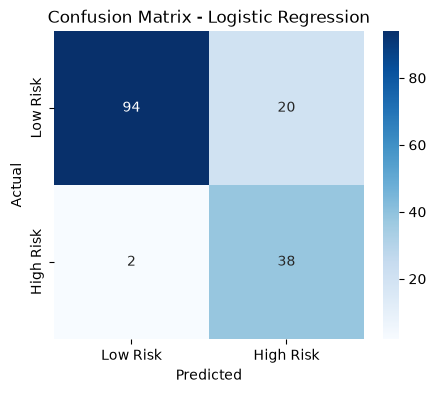

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_logreg = confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=["Low Risk", "High Risk"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### 8.3 Logistic Regression — Confusion Matrix

The confusion matrix helps us understand where the Logistic Regression model makes correct and incorrect predictions.

For this project, **High Risk** is considered the positive class and **Low Risk** is the negative class.

The confusion matrix is:

| Actual    | Predicted | Result      | Meaning                                                                                |
| --------- | --------- | ----------- | -------------------------------------------------------------------------------------- |
| Low Risk  | Low Risk  | **TN = 94** | 94 Low Risk patients were correctly classified.                                        |
| Low Risk  | High Risk | **FP = 20** | 20 Low Risk patients were incorrectly classified as High Risk. These are false alarms. |
| High Risk | Low Risk  | **FN = 2**  | 2 High Risk patients were incorrectly classified as Low Risk. These are missed cases.  |
| High Risk | High Risk | **TP = 38** | 38 High Risk patients were correctly classified.                                       |

#### Interpretation

* **TN = 94:** The model correctly identified 94 Low Risk patients.
* **FP = 20:** The model incorrectly classified 20 Low Risk patients as High Risk.
* **FN = 2:** The model missed 2 High Risk patients.
* **TP = 38:** The model correctly identified 38 High Risk patients.

The model correctly classified **132 out of 154 patients**.

The most important observation is that the model detected **38 out of 40 actual High Risk patients**, which explains the high **Recall of 95%**. However, it also produced **20 false positives**, which explains why the **Precision is lower at 65.52%**.


### 8.4 KNN — Make Predictions

The KNN model has already been trained using the SMOTE-balanced training data.

We now use the trained KNN model to predict the classes of the patients in the test set.

The predictions will then be compared with the actual values to evaluate the model.


In [45]:
knn = models["KNN"]

y_pred_knn = knn.predict(X_test_scaled)

y_pred_knn

array(['High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'High Risk', 'High Risk', 'High Risk',
       'High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk

In [46]:
len(y_pred_knn)

154

In [47]:
comparison_knn = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_knn
})

comparison_knn.head(30)

,Actual,Predicted
0,High Risk,High Risk
1,High Risk,High Risk
2,Low Risk,Low Risk
3,Low Risk,Low Risk
4,High Risk,High Risk
5,Low Risk,Low Risk
6,Low Risk,Low Risk
7,Low Risk,Low Risk
8,Low Risk,Low Risk
9,Low Risk,Low Risk


### 8.5 KNN — Model Evaluation

We now evaluate the KNN model by comparing its predictions with the actual values from the test set.

We will use four metrics:

* **Accuracy:** How many predictions were correct overall?
* **Precision:** When the model predicts the positive class, how often is it correct?
* **Recall:** How many of the actual positive cases did the model find?
* **F1-score:** A balance between Precision and Recall.


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    pos_label="High Risk"
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    pos_label="High Risk"
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    pos_label="High Risk"
)

print("KNN")
print("-------------------")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1-score :", f1_knn)

KNN
-------------------
Accuracy : 0.8766233766233766
Precision: 0.6909090909090909
Recall   : 0.95
F1-score : 0.8


### 8.6 KNN — Confusion Matrix

The confusion matrix shows how the KNN model's predictions are distributed between correct and incorrect predictions.

For this project:

* **High Risk** = positive class
* **Low Risk** = negative class

The confusion matrix helps us identify:

* **True Positive (TP):** correctly predicted High Risk
* **True Negative (TN):** correctly predicted Low Risk
* **False Positive (FP):** predicted High Risk, but actually Low Risk
* **False Negative (FN):** predicted Low Risk, but actually High Risk

This helps us understand not only how many predictions are correct, but also what type of mistakes the model makes.


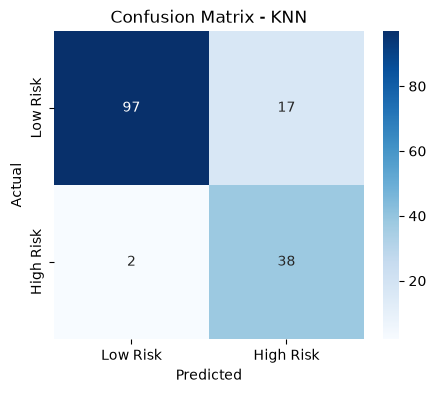

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=["Low Risk", "High Risk"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

### 8.6 KNN — Confusion Matrix

The confusion matrix allows us to analyze the predictions made by the KNN model for the two classes: **Low Risk** and **High Risk**.

For this project, **High Risk** is considered the positive class.

The results are:

* **True Negative (TN) = 97:** 97 patients who were actually Low Risk were correctly classified as Low Risk.
* **False Positive (FP) = 17:** 17 patients who were actually Low Risk were incorrectly classified as High Risk.
* **False Negative (FN) = 2:** 2 patients who were actually High Risk were incorrectly classified as Low Risk.
* **True Positive (TP) = 38:** 38 patients who were actually High Risk were correctly classified as High Risk.

The KNN model therefore detected **38 out of 40 High Risk patients**, resulting in a **95% recall**.

The **2 False Negatives** are particularly important because they represent High Risk patients that the model failed to identify.


### 8.7 Random Forest — Prediction

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

Each tree makes a prediction, and the Random Forest combines their predictions to produce the final classification.

We use the trained Random Forest model to predict the risk category of the unseen test data.

* `X_test_scaled` contains the unseen patient features.
* `y_pred_rf` will contain the predictions made by the Random Forest.
* We will then compare these predictions with `y_test` to evaluate the model.


In [50]:
rf = models["Random Forest"]

y_pred_rf = rf.predict(X_test_scaled)

y_pred_rf

array(['High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'High Risk', 'High Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk',

In [51]:
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

comparison_rf.head(30)

,Actual,Predicted
0,High Risk,High Risk
1,High Risk,High Risk
2,Low Risk,Low Risk
3,Low Risk,Low Risk
4,High Risk,High Risk
5,Low Risk,Low Risk
6,Low Risk,Low Risk
7,Low Risk,Low Risk
8,Low Risk,Low Risk
9,Low Risk,Low Risk


### 8.7 Random Forest — Evaluation Metrics

We evaluate the Random Forest model using four metrics: **Accuracy, Precision, Recall, and F1-score**.

These metrics allow us to compare the Random Forest model with the previous models.

* **Accuracy:** measures the proportion of all predictions that are correct.
* **Precision:** measures how many patients predicted as High Risk are actually High Risk.
* **Recall:** measures how many actual High Risk patients were correctly identified.
* **F1-score:** combines Precision and Recall into a single metric.

Since **High Risk** is the positive class, Precision, Recall, and F1-score focus on the model's ability to identify High Risk patients.


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    pos_label="High Risk"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label="High Risk"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    pos_label="High Risk"
)

print("Random Forest")
print("-------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)

Random Forest
-------------------
Accuracy : 0.935064935064935
Precision: 0.8260869565217391
Recall   : 0.95
F1-score : 0.8837209302325582


### 8.8 Random Forest — Confusion Matrix

The confusion matrix allows us to analyze the types of correct and incorrect predictions made by the Random Forest model.

For this project, **High Risk** is considered the positive class.

The matrix contains four values:

* **True Negative (TN):** Low Risk correctly predicted as Low Risk.
* **False Positive (FP):** Low Risk incorrectly predicted as High Risk.
* **False Negative (FN):** High Risk incorrectly predicted as Low Risk.
* **True Positive (TP):** High Risk correctly predicted as High Risk.

This allows us to see exactly which types of errors the Random Forest model makes, especially the number of **False Negatives**, which represent High Risk cases that were missed.


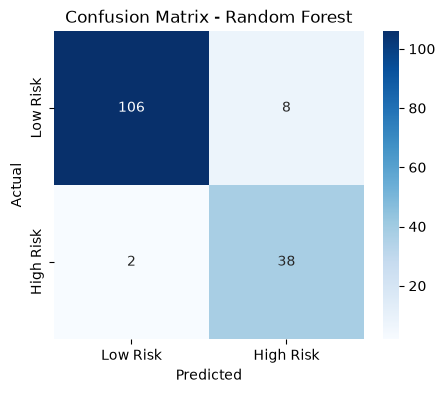

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Low Risk", "High Risk"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

### Random Forest — Confusion Matrix Interpretation

The Random Forest confusion matrix shows the following results:

* **True Negative (TN) = 106:** 106 Low Risk patients were correctly classified as Low Risk.
* **False Positive (FP) = 8:** 8 Low Risk patients were incorrectly classified as High Risk.
* **False Negative (FN) = 2:** 2 High Risk patients were incorrectly classified as Low Risk.
* **True Positive (TP) = 38:** 38 High Risk patients were correctly classified as High Risk.

The model correctly identified **38 out of 40 High Risk patients**, resulting in a **95% recall**.

Only **2 High Risk cases were missed**, while the number of False Positives was relatively low at **8 cases**.

Overall, the confusion matrix confirms the strong performance of the Random Forest model, with a good ability to identify High Risk patients while reducing false alarms.


### 8.9 SVM — Prediction

Support Vector Machine (SVM) is a supervised classification algorithm that tries to find the best boundary, called a **hyperplane**, to separate different classes.

In our project, SVM will classify patients into:

* **Low Risk**
* **High Risk**

We use the trained SVM model to predict the classes of the unseen test data.

The predictions will then be compared with the actual values to evaluate the model's performance.


In [54]:
svm = models["SVM"]

y_pred_svm = svm.predict(X_test_scaled)

y_pred_svm

array(['High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'High Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'High Risk', 'High Risk', 'Low Risk', 'High Risk',
       'Low Risk', 'High Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'High Risk', 'High Risk', 'High Risk',
       'High Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk',
       'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk',
       'Low Risk', 'Low Risk', 'Low Risk'

In [55]:
comparison_svm = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})

comparison_svm.head(30)

,Actual,Predicted
0,High Risk,High Risk
1,High Risk,High Risk
2,Low Risk,Low Risk
3,Low Risk,Low Risk
4,High Risk,High Risk
5,Low Risk,Low Risk
6,Low Risk,Low Risk
7,Low Risk,Low Risk
8,Low Risk,Low Risk
9,Low Risk,Low Risk


### 8.10 SVM — Evaluation Metrics

We evaluate the SVM model using four classification metrics:

* **Accuracy:** proportion of all predictions that are correct.
* **Precision:** proportion of predicted High Risk patients that are actually High Risk.
* **Recall:** proportion of actual High Risk patients correctly identified by the model.
* **F1-score:** combines Precision and Recall to provide a balanced evaluation.

Because **High Risk** is the positive class, Precision, Recall, and F1-score focus on the model's ability to correctly identify High Risk patients.


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    pos_label="High Risk"
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    pos_label="High Risk"
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    pos_label="High Risk"
)

print("SVM")
print("-------------------")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1-score :", f1_svm)

SVM
-------------------
Accuracy : 0.9415584415584416
Precision: 0.8444444444444444
Recall   : 0.95
F1-score : 0.8941176470588236


### 8.10 SVM — Confusion Matrix

The confusion matrix allows us to analyze the correct and incorrect predictions made by the SVM model.

For this project, **High Risk** is considered the positive class.

The matrix contains four possible outcomes:

* **True Negative (TN):** Low Risk correctly predicted as Low Risk.
* **False Positive (FP):** Low Risk incorrectly predicted as High Risk.
* **False Negative (FN):** High Risk incorrectly predicted as Low Risk.
* **True Positive (TP):** High Risk correctly predicted as High Risk.

This allows us to understand the types of errors made by the SVM model, especially the number of **False Negatives**, which represent High Risk cases that were missed.


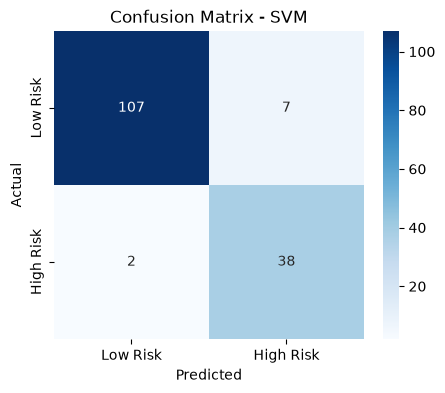

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["Low Risk", "High Risk"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

### SVM — Confusion Matrix Interpretation

The SVM confusion matrix shows the following results:

* **True Negative (TN) = 107:** 107 Low Risk patients were correctly classified as Low Risk.
* **False Positive (FP) = 7:** 7 Low Risk patients were incorrectly classified as High Risk.
* **False Negative (FN) = 2:** 2 High Risk patients were incorrectly classified as Low Risk.
* **True Positive (TP) = 38:** 38 High Risk patients were correctly classified as High Risk.

The model correctly identified **38 out of 40 High Risk patients**, resulting in a **95% recall**.

Only **2 High Risk cases were missed**, while only **7 Low Risk patients were incorrectly classified as High Risk**.

Overall, the confusion matrix confirms the strong performance of the SVM model. It provides a good balance between detecting High Risk patients and limiting false alarms.


### 9. Comparison of Classification Models

After training and evaluating the four classification models, we compare their performance using **Accuracy, Precision, Recall, and F1-score**.

The goal is to identify the model that provides the best overall performance for predicting the **High Risk** and **Low Risk** categories.

Since identifying High Risk patients is important in this project, particular attention is given to **Recall and F1-score**, while also considering Accuracy and Precision.

The model with the best overall performance will be selected for the next step: **hyperparameter tuning**.


In [58]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_logreg,
        accuracy_knn,
        accuracy_rf,
        accuracy_svm
    ],
    "Precision": [
        precision_logreg,
        precision_knn,
        precision_rf,
        precision_svm
    ],
    "Recall": [
        recall_logreg,
        recall_knn,
        recall_rf,
        recall_svm
    ],
    "F1-score": [
        f1_logreg,
        f1_knn,
        f1_rf,
        f1_svm
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.857143,0.655172,0.95,0.775510
1,KNN,0.876623,0.690909,0.95,0.800000
2,Random Forest,0.935065,0.826087,0.95,0.883721
3,SVM,0.941558,0.844444,0.95,0.894118


### Model Comparison Interpretation

The comparison shows that **SVM achieves the best overall performance** among the four tested models.

SVM obtains:

* **94.16% Accuracy**
* **84.44% Precision**
* **95% Recall**
* **89.41% F1-score**

Random Forest is the second-best model, with an F1-score of **88.37%**.

All four models achieved the same **95% Recall**, meaning they identified 95% of the actual High Risk cases.

However, SVM achieved the highest Accuracy, Precision, and F1-score. Therefore, **SVM is selected as the best baseline model for the next step: hyperparameter tuning**.
